# EMNIST Character Classification using HOG + SVM + LOOCV

Nama: Yosua Dirgana Pratama  
NIM: 4222301009

Metode:
- HOG (Histogram of Oriented Gradients)
- SVM (Support Vector Machine)
- Leave-One-Out Cross Validation (LOOCV)

Dataset:
EMNIST Balanced Dataset

1. Pre-requisites

Installation of the following dependencies


In [1]:
!pip3 install matplotlib numpy seaborn scikit-learn scikit-image mlxtend


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Dataset Preparation

Import library yang diperlukan untuk proses klasifikasi EMNIST.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd

from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    f1_score
)


To confirm whether the dataset already downloaded, use this following command

In [3]:
data = pd.read_csv(
r"D:\Computer Vision\EMNIST\emnist-letters-train.csv",
header=None
)

data_labels = data.iloc[:,0].values
data_img = data.iloc[:,1:].values

print("Total images:",len(data_img))
print("Total labels:",len(data_labels))

Total images: 88800
Total labels: 88800


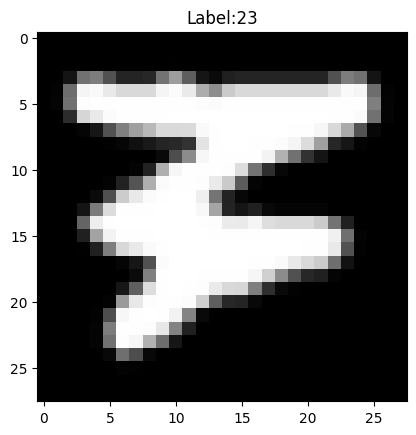

In [4]:
plt.imshow(
data_img[0].reshape(28,28),
cmap="gray"
)

plt.title(
f"Label:{data_labels[0]}"
)

plt.show()

In [5]:
# ambil label dan pixel dari dataset csv
data_labels = data.iloc[:,0].values
data_img = data.iloc[:,1:].values

print(
    "Total images:",
    len(data_img)
)

print(
    "Total labels:",
    len(data_labels)
)

# ubah label dari 1-26 menjadi 0-25
data_labels = data_labels - 1

# konversi ke numpy
data_img = np.array(data_img)

data_labels = np.array(data_labels)

selected_img=[]

selected_labels=[]

Total images: 88800
Total labels: 88800


In [6]:
for class_idx in range(26):

    idx=np.where(
        data_labels==class_idx
    )[0]

    if len(idx)>=100:

        selected_idx=np.random.choice(
            idx,
            100,
            replace=False
        )

        selected_img.append(
            data_img[selected_idx]
        )

        selected_labels.append(
            data_labels[selected_idx]
        )

    else:

        print(
        f"Class {class_idx} only has {len(idx)}"
        )

In [7]:
X_subset=np.vstack(
selected_img
)

y_subset=np.hstack(
selected_labels
)

print(
"x_subset shape:",
X_subset.shape
)

print(
"y_subset shape:",
y_subset.shape
)

x_subset shape: (2600, 784)
y_subset shape: (2600,)


In [8]:
# Cek apakah data sudah ada
print("X_subset:", X_subset.shape)
print("y_subset:", y_subset.shape)

# Split data train dan test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_subset,
    y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset
)

print("x_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("x_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_subset: (2600, 784)
y_subset: (2600,)
x_train shape: (2080, 784)
y_train shape: (2080,)
x_test shape: (520, 784)
y_test shape: (520,)


In [9]:
from sklearn.model_selection import LeaveOneOut

# pastikan fitur HOG sudah dibuat
try:
    print("X_test_hog shape:", X_test_hog.shape)

    # Initialize LOOCV
    loo = LeaveOneOut()

    print("LOOCV initialized successfully")

    print(
        "Total split example:",
        loo.get_n_splits(X_test_hog)
    )

except NameError:
    print("ERROR: X_test_hog belum dibuat")
    print("Jalankan cell HOG Feature Extraction terlebih dahulu")

ERROR: X_test_hog belum dibuat
Jalankan cell HOG Feature Extraction terlebih dahulu


# 2. Feature Extraction using HOG

In [10]:
feature,hog_img=hog(

X_train[0].reshape(28,28),

orientations=8,

pixels_per_cell=(4,4),

cells_per_block=(2,2),

visualize=True,

block_norm='L2'

)

feature.shape

(1152,)

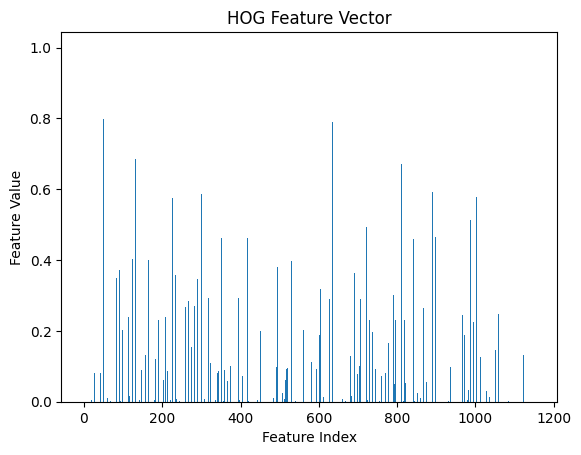

In [11]:
plt.bar(
list(range(feature.shape[0])),
feature
)

plt.title(
"HOG Feature Vector"
)

plt.xlabel(
"Feature Index"
)

plt.ylabel(
"Feature Value"
)

plt.show()

In [12]:
from skimage.feature import hog
import numpy as np

def hog_features(
    images,
    orientations=8,
    pixels_per_cell=(4,4),
    cells_per_block=(2,2)
):
    
    features=[]

    for img in images:

        feature=hog(
            img.reshape(28,28),
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2'
        )

        features.append(feature)

    return np.array(features)

In [13]:
orientations=8

pixels_per_cell=(4,4)

cells_per_block=(2,2)

X_train_hog = hog_features(
    X_train,
    orientations,
    pixels_per_cell,
    cells_per_block
)

X_test_hog = hog_features(
    X_test,
    orientations,
    pixels_per_cell,
    cells_per_block
)

print(
    "HOG feature shape training:",
    X_train_hog.shape
)

print(
    "HOG feature shape testing:",
    X_test_hog.shape
)

HOG feature shape training: (2080, 1152)
HOG feature shape testing: (520, 1152)


# 3. Classification using SVM with LOOCV

Support Vector Machine digunakan sebagai classifier.
Parameter SVM dioptimasi menggunakan Grid Search.

Evaluasi model dilakukan menggunakan Leave One Out Cross Validation (LOOCV), yaitu satu data digunakan sebagai data uji dan sisanya sebagai data latih secara berulang.


In [14]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

loo=LeaveOneOut()

param_grid={

    'C':[0.1,1,10],

    'kernel':['linear','rbf','poly'],

    'gamma':['scale','auto']

}

svm=SVC()

grid_search=GridSearchCV(

    svm,

    param_grid,

    cv=5,

    n_jobs=-1,

    verbose=2

)

grid_search.fit(

    X_train_hog,

    y_train

)

best_model=grid_search.best_estimator_

print(
    "Best Parameter:",
    grid_search.best_params_
)

print(
    "Performance:",
    grid_search.best_estimator_.score(
        X_test_hog,
        y_test
    )
)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameter: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Performance: 0.8423076923076923


In [15]:
print(
    "Best parameters found:",
    grid_search.best_params_
)

print(
    "Performance:",
    grid_search.best_estimator_.score(
        X_test_hog,
        y_test
    )
)

best_model = grid_search.best_estimator_

Best parameters found: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


Performance: 0.8423076923076923


4. Evaluation

In [16]:
from sklearn.metrics import (
    classification_report,
    accuracy_score
)

y_test_pred = best_model.predict(
    X_test_hog
)

print(
    "---Test Set Evaluation---"
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_test_pred
    )
)

print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test,
        y_test_pred
    )
)

---Test Set Evaluation---
Accuracy: 0.8423076923076923

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.80      0.76        20
           1       0.84      0.80      0.82        20
           2       0.83      0.95      0.88        20
           3       0.90      0.90      0.90        20
           4       0.89      0.80      0.84        20
           5       0.75      0.90      0.82        20
           6       0.82      0.70      0.76        20
           7       0.73      0.95      0.83        20
           8       0.71      0.60      0.65        20
           9       0.74      0.85      0.79        20
          10       0.95      0.90      0.92        20
          11       0.70      0.70      0.70        20
          12       1.00      0.95      0.97        20
          13       0.86      0.90      0.88        20
          14       0.95      0.95      0.95        20
          15       0.95      0.90      0.92        20
 

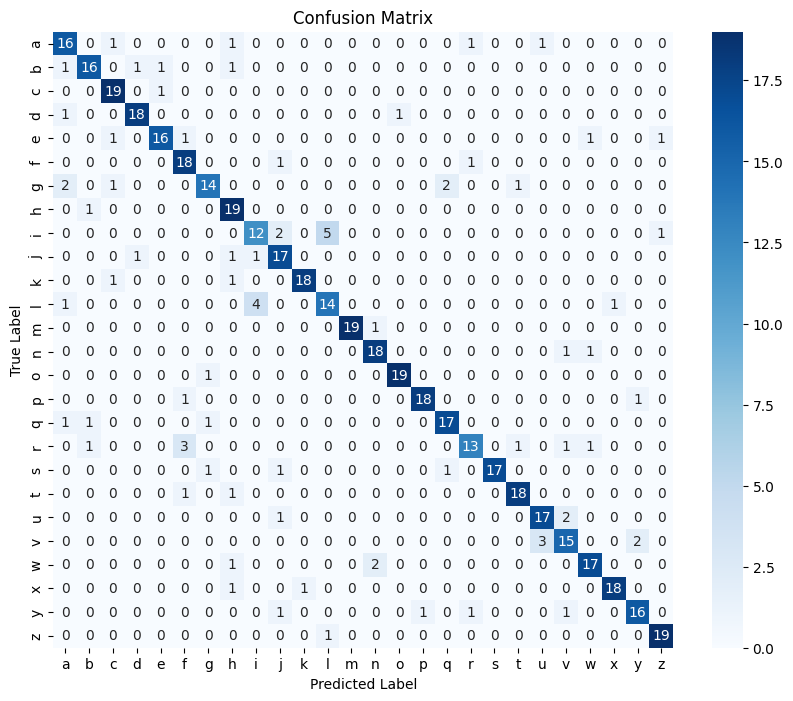

In [17]:
from sklearn.metrics import confusion_matrix

c_mat = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    c_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[chr(i+97) for i in range(26)],
    yticklabels=[chr(i+97) for i in range(26)]
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

5. Prediction Results


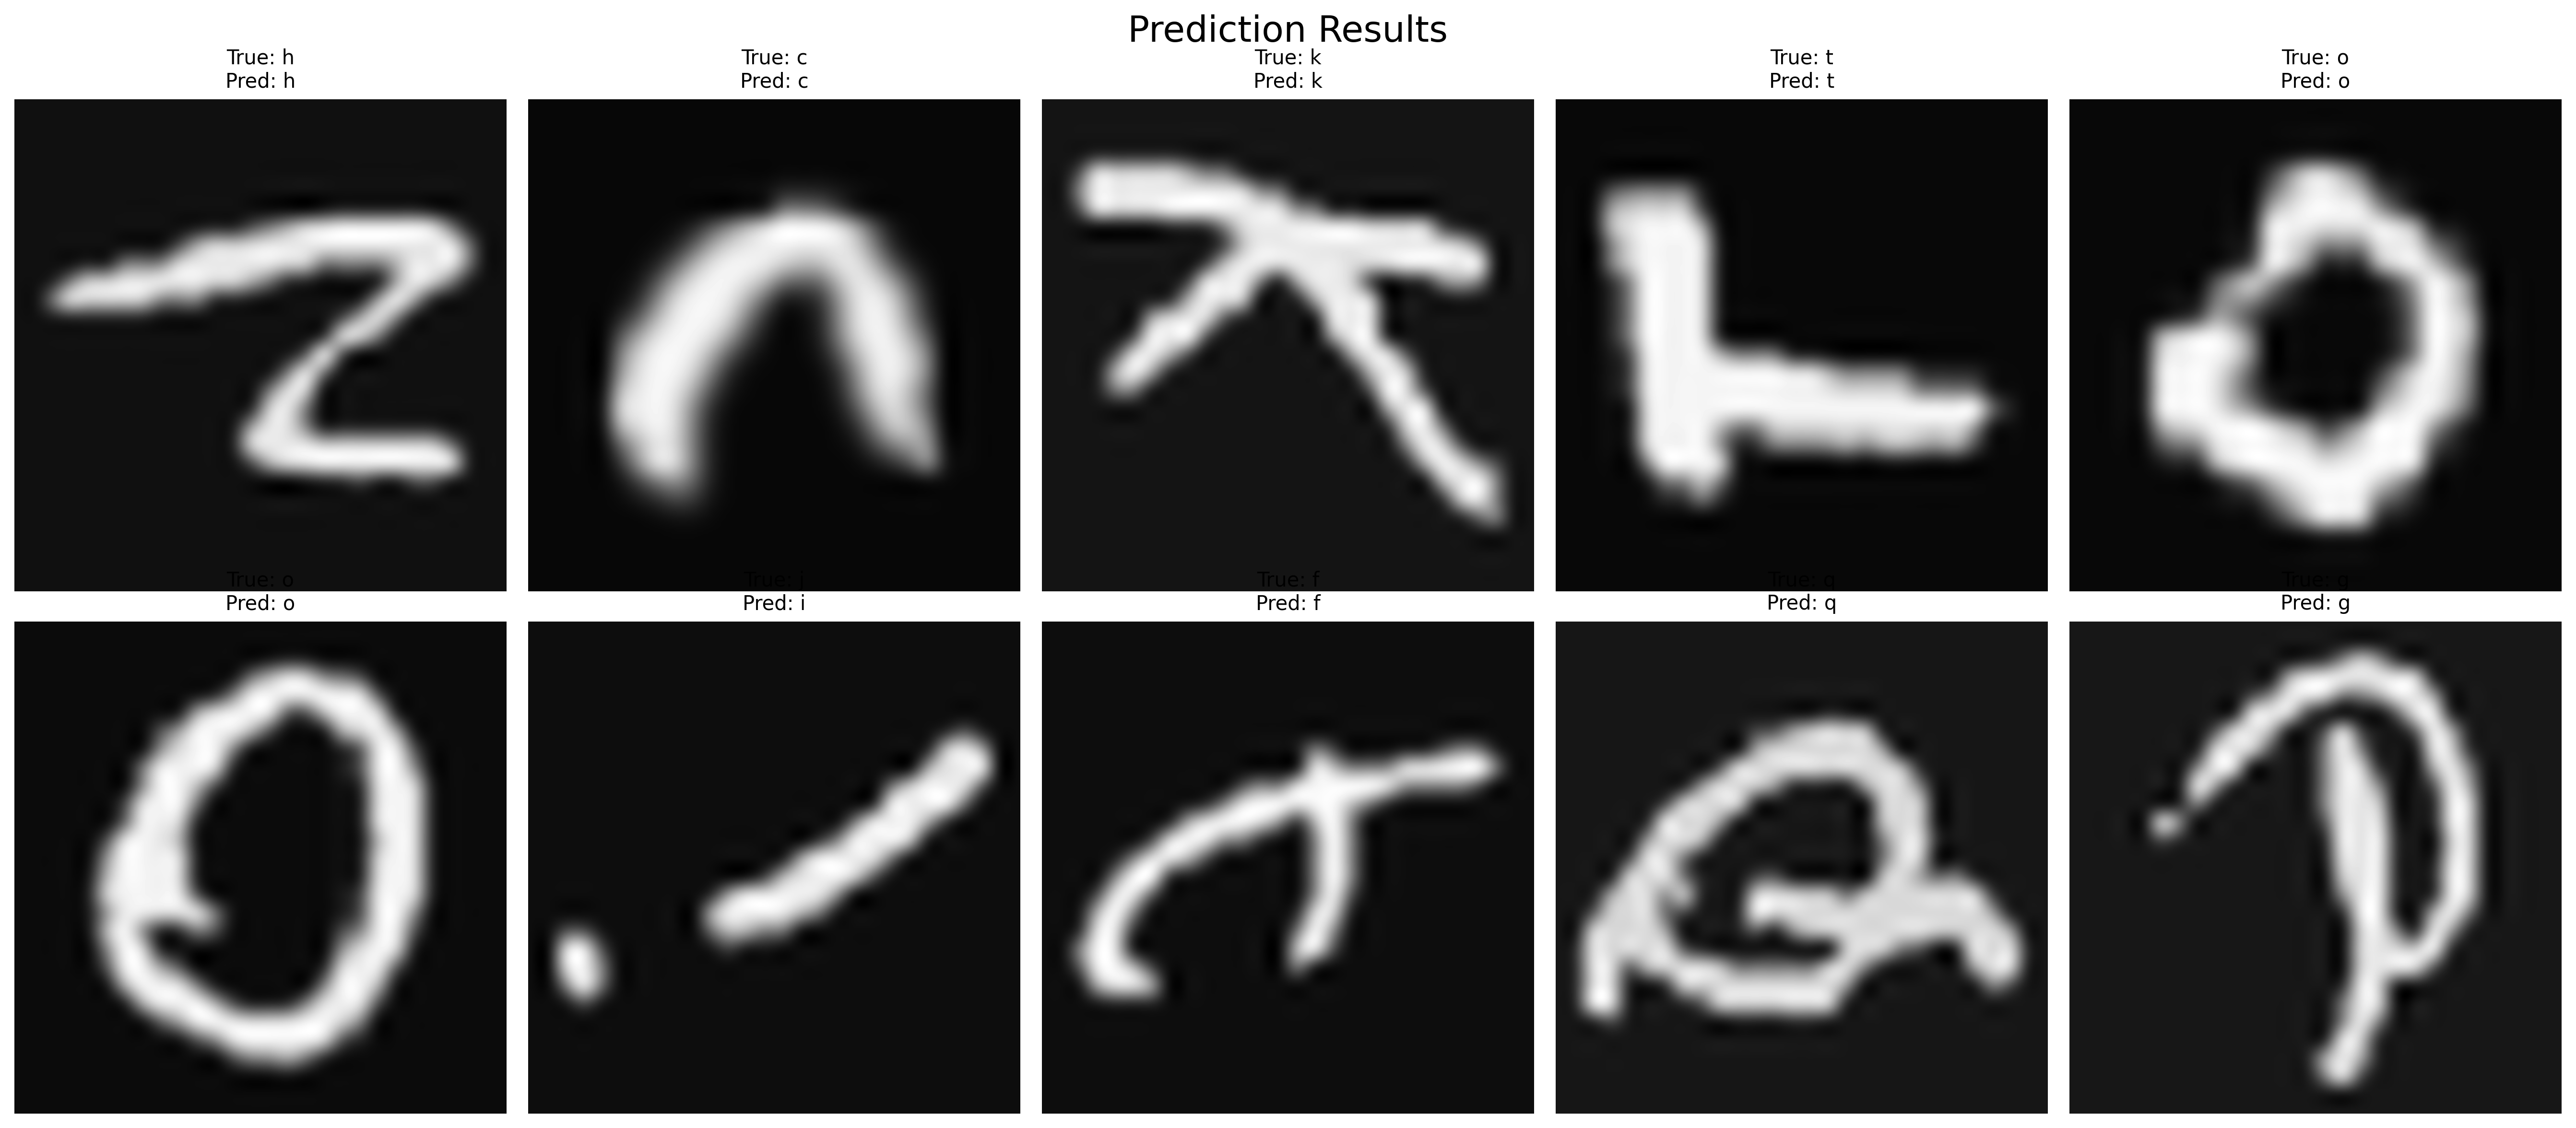

In [18]:
import random
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

# pilih 10 data acak
indices = random.sample(
    range(len(X_test)),
    10
)

# resolusi tinggi
plt.figure(
    figsize=(18,8),
    dpi=300
)

for i, idx in enumerate(indices):

    img = X_test[idx].reshape(28,28)

    # perbesar gambar 8x
    img_large = zoom(
        img,
        8,
        order=3
    )

    true_label = y_test[idx]
    pred_label = y_test_pred[idx]

    plt.subplot(
        2,
        5,
        i+1
    )

    plt.imshow(
        img_large,
        cmap='gray',
        interpolation='bicubic'
    )

    plt.title(
        f"True: {chr(true_label+97)}\nPred: {chr(pred_label+97)}",
        fontsize=10
    )

    plt.axis('off')

plt.suptitle(
    "Prediction Results",
    fontsize=18
)

plt.tight_layout()

plt.show()